In [2]:
#!pip install packaging

In [3]:
# !pip install statsbombpy
# !pip install pandas
# !pip install networkx

In [4]:
import statsbombpy
from statsbombpy import sb
import pandas as pd

In [5]:
matches = sb.matches(competition_id=2, season_id=27)
matches.head()

c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3754058,2016-01-02,16:00:00.000,England - Premier League,2015/2016,Leicester City,AFC Bournemouth,0,0,available,...,2021-06-12T16:17:31.694,20,Regular Season,King Power Stadium,Andre Marriner,Claudio Ranieri,Eddie Howe,1.1.0,2,2
1,3754245,2015-10-17,16:00:00.000,England - Premier League,2015/2016,West Bromwich Albion,Sunderland,1,0,available,...,2021-06-13T16:17:31.694,9,Regular Season,The Hawthorns,Martin Atkinson,Tony Pulis,Sam Allardyce,1.1.0,2,2
2,3754136,2015-12-19,18:30:00.000,England - Premier League,2015/2016,Newcastle United,Aston Villa,1,1,available,...,2021-06-13T16:17:31.694,17,Regular Season,St. James'' Park,Martin Atkinson,Steve McClaren,Rémi Garde,1.1.0,2,2
3,3754037,2016-04-30,16:00:00.000,England - Premier League,2015/2016,Everton,AFC Bournemouth,2,1,available,...,2021-06-12T16:17:31.694,36,Regular Season,Goodison Park,Neil Swarbrick,Roberto Martínez Montoliú,Eddie Howe,1.1.0,2,2
4,3754039,2016-02-13,16:00:00.000,England - Premier League,2015/2016,Crystal Palace,Watford,1,2,available,...,2021-06-12T16:17:31.694,26,Regular Season,Selhurst Park,Robert Madley,Alan Pardew,Enrique Sánchez Flores,1.1.0,2,2


In [6]:
# Get the first match ID
match_id = matches.iloc[0]['match_id']

# Load event data
events = sb.events(match_id=match_id)
events.head()

c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Leicester City,22,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",AFC Bournemouth,28,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Leicester City,22,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN


In [7]:
all_events = []
for match_id in matches['match_id']:
    events = sb.events(match_id=match_id)
    events['match_id'] = match_id
    all_events.append(events)

# Combine into one big DataFrame
pl_2015_2016_events = pd.concat(all_events, ignore_index=True)

c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\s

In [8]:
pl_2015_2016_events.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
leicester_matches = matches[(matches['home_team'] == "Leicester City") | 
                            (matches['away_team'] == "Leicester City")]

In [10]:
events_list = []
for match_id in leicester_matches['match_id']:
    df = sb.events(match_id=match_id)
    events_list.append(df)

events = pd.concat(events_list, ignore_index=True)

c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\s

In [11]:
import numpy as np

In [12]:
# copy to avoid SettingWithCopyWarning and extract X coordinate from location
lec_events = events[events['team'] == 'Leicester City'].copy()
lec_events['x'] = lec_events['location'].apply(
    lambda loc: loc[0] if isinstance(loc, (list, tuple)) and len(loc) >= 1 else np.nan
)

In [13]:
# filter to attacking third (x between 80 and 120)
att_third = lec_events[(lec_events['x'] >= 80) & (lec_events['x'] <= 120)].copy()

In [14]:
# mark unsuccessful dribbles where type == 'Dribble' and dribble_outcome == 'Incomplete'
att_third['unsuccessful_dribble'] = (
    (att_third['type'] == 'Dribble') & (att_third['dribble_outcome'] == 'Incomplete')
).astype(int)

# aggregate per player using only attacking-third events
possession_ending_actions = att_third.groupby('player').agg(
    shots=('type', lambda x: (x == 'Shot').sum()),
    dispossessed=('type', lambda x: (x == 'Dispossessed').sum()),
    miscontrols=('type', lambda x: (x == 'Miscontrol').sum()),
    incomplete_passes=('pass_outcome', lambda x: x.notna().sum()),
    unsuccessful_dribbles=('unsuccessful_dribble', 'sum')
).reset_index()

In [15]:
cols = ['shots','dispossessed','miscontrols','incomplete_passes','unsuccessful_dribbles']
possession_ending_actions[cols] = possession_ending_actions[cols].fillna(0).astype(int)
possession_ending_actions['possession_ending_actions'] = possession_ending_actions[cols].sum(axis=1)


In [16]:
possession_ending_actions

,player,shots,dispossessed,miscontrols,incomplete_passes,unsuccessful_dribbles,possession_ending_actions
0,Andrej Kramarić,1,0,1,2,0,4
1,Andrew Philip King,19,3,2,31,3,58
2,Christian Fuchs,19,3,7,188,1,218
3,Daniel Amartey,1,2,0,3,1,7
4,Danny Drinkwater,42,16,7,94,3,162
5,Danny Simpson,7,4,3,89,6,109
6,Demarai Gray,5,4,3,14,2,28
7,Gökhan İnler,2,0,0,6,1,9
8,Jamie Vardy,118,30,58,154,30,390
9,Jeffrey Schlupp,25,23,20,56,15,139


In [17]:
# find possession_ending actions for Leceister City as a team
shots = (att_third['type'] == 'Shot').sum()
dispossessed = (att_third['type'] == 'Dispossessed').sum()
miscontrols = (att_third['type'] == 'Miscontrol').sum()
incomplete_passes = att_third['pass_outcome'].notna().sum()
unsuccessful_dribbles = att_third['unsuccessful_dribble'].sum()

In [18]:
team_totals = pd.DataFrame([{
    'team': 'Leicester City',
    'shots': shots,
    'dispossessed': dispossessed,
    'miscontrols': miscontrols,
    'incomplete_passes': incomplete_passes,
    'unsuccessful_dribbles': unsuccessful_dribbles,
    'possession ending actions': (shots + dispossessed + miscontrols + incomplete_passes + unsuccessful_dribbles)
}])
team_totals

,team,shots,dispossessed,miscontrols,incomplete_passes,unsuccessful_dribbles,possession ending actions
0,Leicester City,525,245,275,1382,183,2610


# Change to per90 numbers
# Add chances created per 90 - find G/Aper90 as well, so we can compare usage rate to these numbers - look at wyscout

In [19]:
duel_values = lec_events['duel_outcome'].value_counts(dropna=False)
duel_values

duel_outcome
NaN                55700
Success In Play      292
Won                  210
Lost Out             172
Lost In Play         167
Success Out           26
Name: count, dtype: int64

In [20]:
type_values = lec_events['type'].value_counts(dropna=False)
type_values

# find values for when 'type' equals Dribble
dribble_values = lec_events[lec_events['type'] == 'Dribble']
dribble_values['dribble_outcome'].value_counts(dropna=False)

dribble_outcome
Complete      429
Incomplete    296
Name: count, dtype: int64

In [21]:
# create usage rate by dividing player possession ending actions by team total, and display usage rate with two decimal places
possession_ending_actions['Usage Rate'] = ((possession_ending_actions['possession_ending_actions'] / team_totals['possession ending actions'].values[0]) * 100).round(2)

In [22]:
possession_ending_actions 

,player,shots,dispossessed,miscontrols,incomplete_passes,unsuccessful_dribbles,possession_ending_actions,Usage Rate
0,Andrej Kramarić,1,0,1,2,0,4,0.15
1,Andrew Philip King,19,3,2,31,3,58,2.22
2,Christian Fuchs,19,3,7,188,1,218,8.35
3,Daniel Amartey,1,2,0,3,1,7,0.27
4,Danny Drinkwater,42,16,7,94,3,162,6.21
5,Danny Simpson,7,4,3,89,6,109,4.18
6,Demarai Gray,5,4,3,14,2,28,1.07
7,Gökhan İnler,2,0,0,6,1,9,0.34
8,Jamie Vardy,118,30,58,154,30,390,14.94
9,Jeffrey Schlupp,25,23,20,56,15,139,5.33


In [23]:
# !pip install statsbombpy
# !pip install pandas
# !pip install networkx
# !pip install soccerdata
# !pip install setuptools
# !pip install pyarrow
# !pip install polars

In [24]:
import sys, subprocess

print("Python executable:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "show", "soccerdata"])

Python executable: c:\Users\jonat\AppData\Local\Programs\Python\Python311\python.exe


CompletedProcess(args=['c:\\Users\\jonat\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'show', 'soccerdata'], returncode=0)

In [25]:
import soccerdata as sd

[12/02/25 18:28:36] INFO     No custom team name replacements found. You can configure these in       ]8;id=958302;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=31029;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_config.py#91\91]8;;\
                             C:\Users\jonat\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=53342;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=866347;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_config.py#197\197]8;;\
                             C:\Users\jonat\soccerdata\config\league_dict.json.                                    

In [26]:
import warnings
from statsbombpy.api_client import NoAuthWarning

warnings.filterwarnings("ignore", category=NoAuthWarning)

In [27]:
fb = sd.FBref(leagues = "Big 5 European Leagues Combined", seasons = '15-16', no_cache = False, no_store = False)

[12/02/25 18:28:38] INFO     Saving cached data to C:\Users\jonat\soccerdata\data\FBref              ]8;id=292916;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=37670;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packages\soccerdata\_common.py#263\263]8;;\

In [28]:
# Loading Player Stats
# Step 1: load the standard stats for all Big 5 leagues
player_stats = fb.read_player_season_stats(stat_type="standard")

# Step 2: filter for Premier League only
player_stats = player_stats.loc["ENG-Premier League"]

# Take a look
player_stats.head()

[12/02/25 18:28:39] WARNING  c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packag ]8;id=18503;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=946574;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             es\soccerdata\fbref.py:165: FutureWarning: The behavior of DataFrame                  
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

nation    pos age  born Playing Time  \
                                                                         MP   
season team    player                                                         
1516   Arsenal Aaron Ramsey               WAL     MF  24  1990           31   
               Alex Iwobi                 NGA  FW,MF  19  1996           13   
               Alex Oxlade-Chamberlain    ENG  FW,MF  21  1993           22   
               Alexis Sánchez             CHI  FW,MF  26  1988           30   
               Calum Chambers             ENG  DF,MF  20  1995           12   

                                                          Performance      \
                                       Starts   Min   90s         Gls Ast   
season team    player                                                       
1516   Arsenal Aaron Ramsey                29  2623  29.1           5   4   
               Alex Iwobi                   8   628   7.0           2   2   
               Alex Oxlade-Chamberlain      9   926  10.3           1   0   
               Alexis Sánchez              28  2436  27.1          13   4   
               Calum Chambers               2   322   3.6           0   0   

                                        ...                          \
                                        ... G-PK PK PKatt CrdY CrdR   
season team    player                   ...                           
1516   Arsenal Aaron Ramsey             ...    5  0     0    4    0   
               Alex Iwobi               ...    2  0     0    0    0   
               Alex Oxlade-Chamberlain  ...    1  0     0    0    0   
               Alexis Sánchez           ...   13  0     0    1    0   
               Calum Chambers           ...    0  0     0    2    0   

                                       Per 90 Minutes                           
                                                  Gls   Ast   G+A  G-PK G+A-PK  
season team    player                                                           
1516   Arsenal Aaron Ramsey                      0.17  0.14  0.31  0.17   0.31  
               Alex Iwobi                        0.29  0.29  0.57  0.29   0.57  
               Alex Oxlade-Chamberlain            0.1   0.0   0.1   0.1    0.1  
               Alexis Sánchez                    0.48  0.15  0.63  0.48   0.63  
               Calum Chambers                     0.0   0.0   0.0   0.0    0.0  

[5 rows x 21 columns]

In [29]:
def clean_player_stats_columns(player_stats: pd.DataFrame) -> pd.DataFrame:
    df = player_stats.copy()

    new_cols = []
    for col in df.columns:
        # MultiIndex entries: (top, sub)
        if isinstance(col, tuple):
            top, sub = col

            # nation, pos, age, born (where sub == '')
            if top == 'nation' and sub == '':
                new_cols.append('nation')
            elif top == 'pos' and sub == '':
                new_cols.append('pos')
            elif top == 'age' and sub == '':
                new_cols.append('age')
            elif top == 'born' and sub == '':
                new_cols.append('born')

            # Playing Time
            elif top == 'Playing Time' and sub == 'MP':
                new_cols.append('matches')
            elif top == 'Playing Time' and sub == 'Starts':
                new_cols.append('starts')
            elif top == 'Playing Time' and sub == 'Min':
                new_cols.append('minutes')
            elif top == 'Playing Time' and sub == '90s':
                new_cols.append('nineties')

            # Performance (counting stats)
            elif top == 'Performance' and sub == 'Gls':
                new_cols.append('goals')
            elif top == 'Performance' and sub == 'Ast':
                new_cols.append('assists')
            elif top == 'Performance' and sub == 'G+A':
                new_cols.append('g_plus_a')
            elif top == 'Performance' and sub == 'G-PK':
                new_cols.append('non_pen_goals')
            elif top == 'Performance' and sub == 'PK':
                new_cols.append('penalties_scored')
            elif top == 'Performance' and sub == 'PKatt':
                new_cols.append('penalties_attempted')
            elif top == 'Performance' and sub == 'CrdY':
                new_cols.append('yellow_cards')
            elif top == 'Performance' and sub == 'CrdR':
                new_cols.append('red_cards')

            # Per 90 Minutes
            elif top == 'Per 90 Minutes' and sub == 'Gls':
                new_cols.append('goals_p90')
            elif top == 'Per 90 Minutes' and sub == 'Ast':
                new_cols.append('assists_p90')
            elif top == 'Per 90 Minutes' and sub == 'G+A':
                new_cols.append('g_plus_a_p90')
            elif top == 'Per 90 Minutes' and sub == 'G-PK':
                new_cols.append('non_pen_goals_p90')
            elif top == 'Per 90 Minutes' and sub == 'G+A-PK':
                new_cols.append('g_plus_a_minus_pk_p90')

            # Fallback: if some unexpected (top, sub) shows up
            else:
                new_cols.append(f"{top}_{sub}".strip())

        # Scalar columns like 'season', 'team', 'player'
        else:
            new_cols.append(col)

    df.columns = new_cols

    df = df.reset_index()
    first_col = df.columns[0]
    df = df.drop(columns=[first_col])

    return df


In [30]:
player_stats = clean_player_stats_columns(player_stats)

In [31]:
player_stats = player_stats.reset_index()

In [32]:
player_stats.head()

,index,team,player,nation,pos,age,born,matches,starts,minutes,...,non_pen_goals,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_p90,assists_p90,g_plus_a_p90,non_pen_goals_p90,g_plus_a_minus_pk_p90
0,0,Arsenal,Aaron Ramsey,WAL,MF,24,1990,31,29,2623,...,5,0,0,4,0,0.17,0.14,0.31,0.17,0.31
1,1,Arsenal,Alex Iwobi,NGA,"FW,MF",19,1996,13,8,628,...,2,0,0,0,0,0.29,0.29,0.57,0.29,0.57
2,2,Arsenal,Alex Oxlade-Chamberlain,ENG,"FW,MF",21,1993,22,9,926,...,1,0,0,0,0,0.1,0.0,0.1,0.1,0.1
3,3,Arsenal,Alexis Sánchez,CHI,"FW,MF",26,1988,30,28,2436,...,13,0,0,1,0,0.48,0.15,0.63,0.48,0.63
4,4,Arsenal,Calum Chambers,ENG,"DF,MF",20,1995,12,2,322,...,0,0,0,2,0,0.0,0.0,0.0,0.0,0.0


In [33]:
#Loading Team Stats
team_stats = fb.read_team_season_stats(stat_type="standard")

team_stats = team_stats.loc["ENG-Premier League"]

team_stats.head()

[12/02/25 18:28:42] WARNING  c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\site-packag ]8;id=129477;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=777455;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             es\soccerdata\fbref.py:165: FutureWarning: The behavior of DataFrame                  
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

players_used   Age  Poss Playing Time                   \
                                                         MP Starts   Min 90s   
season team                                                                    
1516   Arsenal                  25  27.0  58.3           38    418  3420  38   
       Aston Villa              29  26.6  46.4           38    418  3420  38   
       Bournemouth              28  27.7  51.2           38    418  3420  38   
       Chelsea                  28  26.8  56.2           38    418  3420  38   
       Crystal Palace           30  27.7  45.8           38    418  3420  38   

                      Performance           ...                     \
                              Gls Ast  G+A  ... PK PKatt CrdY CrdR   
season team                                 ...                      
1516   Arsenal                 62  53  115  ...  1     2   45    0   
       Aston Villa             24  19   43  ...  2     2   77    0   
       Bournemouth             43  28   71  ...  3     4   53    0   
       Chelsea                 55  40   95  ...  4     5   62    0   
       Crystal Palace          38  21   59  ...  4     5   62    0   

                      Per 90 Minutes                           \
                                 Gls   Ast   G+A  G-PK G+A-PK   
season team                                                     
1516   Arsenal                  1.63  1.39  3.03  1.61    3.0   
       Aston Villa              0.63   0.5  1.13  0.58   1.08   
       Bournemouth              1.13  0.74  1.87  1.05   1.79   
       Chelsea                  1.45  1.05   2.5  1.34   2.39   
       Crystal Palace            1.0  0.55  1.55  0.89   1.45   

                                                                     url  
                                                                          
season team                                                               
1516   Arsenal               /en/squads/18bb7c10/2015-2016/Arsenal-Stats  
       Aston Villa       /en/squads/8602292d/2015-2016/Aston-Villa-Stats  
       Bournemouth       /en/squads/4ba7cbea/2015-2016/Bournemouth-Stats  
       Chelsea               /en/squads/cff3d9bb/2015-2016/Chelsea-Stats  
       Crystal Palace  /en/squads/47c64c55/2015-2016/Crystal-Palace-S...  

[5 rows x 21 columns]

In [34]:
team_stats.columns

MultiIndex([(  'players_used',       ''),
            (           'Age',       ''),
            (          'Poss',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK'),
            (           'url',       '')],
           )

In [35]:
def clean_team_stats(team_stats: pd.DataFrame) -> pd.DataFrame:
    df = team_stats.copy()

    # 1) Flatten / rename the MultiIndex columns
    new_cols = []
    for col in df.columns:
        if isinstance(col, tuple):
            top, sub = col

            # simple single-level ones
            if top == 'players_used' and sub == '':
                new_cols.append('players_used')
            elif top == 'Age' and sub == '':
                new_cols.append('avg_age')
            elif top == 'Poss' and sub == '':
                new_cols.append('possession')

            # Playing Time
            elif top == 'Playing Time' and sub == 'MP':
                new_cols.append('matches')
            elif top == 'Playing Time' and sub == 'Starts':
                new_cols.append('starts')
            elif top == 'Playing Time' and sub == 'Min':
                new_cols.append('minutes')
            elif top == 'Playing Time' and sub == '90s':
                new_cols.append('nineties')

            # Performance (totals)
            elif top == 'Performance' and sub == 'Gls':
                new_cols.append('goals')
            elif top == 'Performance' and sub == 'Ast':
                new_cols.append('assists')
            elif top == 'Performance' and sub == 'G+A':
                new_cols.append('g_plus_a')
            elif top == 'Performance' and sub == 'G-PK':
                new_cols.append('non_pen_goals')
            elif top == 'Performance' and sub == 'PK':
                new_cols.append('penalties_scored')
            elif top == 'Performance' and sub == 'PKatt':
                new_cols.append('penalties_attempted')
            elif top == 'Performance' and sub == 'CrdY':
                new_cols.append('yellow_cards')
            elif top == 'Performance' and sub == 'CrdR':
                new_cols.append('red_cards')

            # Per 90 Minutes
            elif top == 'Per 90 Minutes' and sub == 'Gls':
                new_cols.append('goals_p90')
            elif top == 'Per 90 Minutes' and sub == 'Ast':
                new_cols.append('assists_p90')
            elif top == 'Per 90 Minutes' and sub == 'G+A':
                new_cols.append('g_plus_a_p90')
            elif top == 'Per 90 Minutes' and sub == 'G-PK':
                new_cols.append('non_pen_goals_p90')
            elif top == 'Per 90 Minutes' and sub == 'G+A-PK':
                new_cols.append('g_plus_a_minus_pk_p90')

            # url
            elif top == 'url' and sub == '':
                new_cols.append('url')

            # fallback, in case something unexpected shows up
            else:
                new_cols.append(f"{top}_{sub}".strip())
        else:
            # scalar column name
            new_cols.append(col)

    df.columns = new_cols

    # 2) Reset index and split (season, team) if index is tuples
    df = df.reset_index()

    first_col = df.columns[0]
    if df[first_col].apply(lambda x: isinstance(x, tuple)).all():
        tup_len = len(df[first_col].iloc[0])

        if tup_len == 2:
            df[['season', 'team']] = pd.DataFrame(
                df[first_col].tolist(), index=df.index
            )
        elif tup_len == 3:
            df[['season', 'team', 'extra']] = pd.DataFrame(
                df[first_col].tolist(), index=df.index
            )

        df = df.drop(columns=[first_col])

    return df


In [36]:
team_stats = clean_team_stats(team_stats)

In [37]:
team_stats.head()

,season,team,players_used,avg_age,possession,matches,starts,minutes,nineties,goals,...,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_p90,assists_p90,g_plus_a_p90,non_pen_goals_p90,g_plus_a_minus_pk_p90,url
0,1516,Arsenal,25,27.0,58.3,38,418,3420,38,62,...,1,2,45,0,1.63,1.39,3.03,1.61,3.0,/en/squads/18bb7c10/2015-2016/Arsenal-Stats
1,1516,Aston Villa,29,26.6,46.4,38,418,3420,38,24,...,2,2,77,0,0.63,0.5,1.13,0.58,1.08,/en/squads/8602292d/2015-2016/Aston-Villa-Stats
2,1516,Bournemouth,28,27.7,51.2,38,418,3420,38,43,...,3,4,53,0,1.13,0.74,1.87,1.05,1.79,/en/squads/4ba7cbea/2015-2016/Bournemouth-Stats
3,1516,Chelsea,28,26.8,56.2,38,418,3420,38,55,...,4,5,62,0,1.45,1.05,2.5,1.34,2.39,/en/squads/cff3d9bb/2015-2016/Chelsea-Stats
4,1516,Crystal Palace,30,27.7,45.8,38,418,3420,38,38,...,4,5,62,0,1.0,0.55,1.55,0.89,1.45,/en/squads/47c64c55/2015-2016/Crystal-Palace-S...


In [38]:
def get_team_events(team_name, matches_df):
    # Identify matches where the team played
    match_ids = matches_df.query(
        "home_team == @team_name or away_team == @team_name"
    )["match_id"]

    all_events = []

    for mid in match_ids:
        df = sb.events(match_id=mid)

        # Keep only events performed BY this team,
        # during possessions belonging TO this team
        df = df[
            (df["possession_team"] == team_name) &
            (df["team"] == team_name)
        ]

        all_events.append(df)

    return pd.concat(all_events, ignore_index=True)

In [39]:
leicester_events = get_team_events("Leicester City", matches)

In [40]:
leicester_events.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,pass_goal_assist,pass_straight,shot_deflected,goalkeeper_lost_out,goalkeeper_shot_saved_off_target,shot_saved_off_target,block_save_block,goalkeeper_shot_saved_to_post,goalkeeper_success_in_play,shot_saved_to_post
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
merged = pd.merge(
    possession_ending_actions,
    player_stats,
    left_on='player',
    right_on='player',
    how='inner'
)


In [42]:
merged['possession_ending_actions_per90'] = merged['possession_ending_actions'] / merged['nineties']

In [43]:
merged['g_plus_a_minus_pk_p90'] = merged['g_plus_a_p90'] - merged['penalties_scored'] / merged['nineties']

In [44]:
# Repeat for other teams (example: Arsenal, Tottenham)
all_teams = pd.unique(matches[['home_team', 'away_team']].values.ravel())

all_team_dfs = []
for team in all_teams:
    team_events = get_team_events(team, matches)
    team_events['x'] = team_events['location'].apply(
        lambda loc: loc[0] if isinstance(loc, (list, tuple)) and len(loc) >= 1 else np.nan
    )
    att_third = team_events[(team_events['x'] >= 80) & (team_events['x'] <= 120)].copy()
    att_third['unsuccessful_dribble'] = (
        (att_third['type'] == 'Dribble') & (att_third['dribble_outcome'] == 'Incomplete')
    ).astype(int)
    team_actions = att_third.groupby('player').agg(
        shots=('type', lambda x: (x == 'Shot').sum()),
        dispossessed=('type', lambda x: (x == 'Dispossessed').sum()),
        miscontrols=('type', lambda x: (x == 'Miscontrol').sum()),
        incomplete_passes=('pass_outcome', lambda x: x.notna().sum()),
        unsuccessful_dribbles=('unsuccessful_dribble', 'sum')
    ).reset_index()
    cols = ['shots','dispossessed','miscontrols','incomplete_passes','unsuccessful_dribbles']
    team_actions[cols] = team_actions[cols].fillna(0).astype(int)
    team_actions['possession_ending_actions'] = team_actions[cols].sum(axis=1)
    team_merged = pd.merge(
        team_actions,
        player_stats,
        left_on='player',
        right_on='player',
        how='inner'
    )
    team_merged['possession_ending_actions_per90'] = team_merged['possession_ending_actions'] / team_merged['nineties']
    team_merged['g_plus_a_minus_pk_p90'] = team_merged['g_plus_a_p90'] - team_merged['penalties_scored'] / team_merged['nineties']
    team_merged['team'] = team
    # Calculate usage rate for each player
    team_total = team_merged['possession_ending_actions'].sum()
    team_merged['Usage Rate'] = ((team_merged['possession_ending_actions'] / team_total) * 100).round(2)
    all_team_dfs.append(team_merged)

# Combine all teams' player stats into one DataFrame
all_players_stats_df = pd.concat(all_team_dfs, ignore_index=True)

# Example: display columns for all teams
display_cols = ['team', 'player', 'Usage Rate', 'possession_ending_actions', 'possession_ending_actions_per90', 'g_plus_a_p90', 'g_plus_a_minus_pk_p90', 'minutes', 'nineties']
all_players_stats_df[display_cols].sort_values(['team', 'Usage Rate'], ascending=[True, False])

[12/02/25 18:28:58] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=622478;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=117203;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:29:05] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=647349;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=233562;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:29:14] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=241087;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=717217;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:29:23] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=831051;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=671661;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:29:32] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=399306;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=250266;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

...

[12/02/25 18:31:16] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=243513;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=859813;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:31:24] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=82004;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=4742;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:31:32] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=108133;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=204596;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:31:41] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\1869944636.py:7:     ]8;id=939070;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=867927;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

,team,player,Usage Rate,possession_ending_actions,possession_ending_actions_per90,g_plus_a_p90,g_plus_a_minus_pk_p90,minutes,nineties
35,AFC Bournemouth,Matt Ritchie,16.63,400,12.121212,0.3,0.3,2973,33.0
29,AFC Bournemouth,Joshua King,9.85,237,11.126761,0.38,0.38,1913,21.3
30,AFC Bournemouth,Junior Stanislas,9.81,236,14.842767,0.31,0.31,1435,15.9
24,AFC Bournemouth,Charlie Daniels,9.35,225,6.164384,0.22,0.165205,3285,36.5
34,AFC Bournemouth,Marc Pugh,6.90,166,11.14094,0.34,0.34,1337,14.9
...,...,...,...,...,...,...,...,...,...
328,West Ham United,Modibo Maïga,0.53,11,36.666667,3.33,3.33,27,0.3
330,West Ham United,Reece Oxford,0.10,2,0.833333,0.0,0.0,212,2.4
317,West Ham United,Darren Randolph,0.05,1,0.166667,0.0,0.0,540,6.0
324,West Ham United,Kevin Nolan,0.05,1,1.666667,0.0,0.0,57,0.6


In [45]:
#!pip install matplotlib

In [46]:
import matplotlib.pyplot as plt

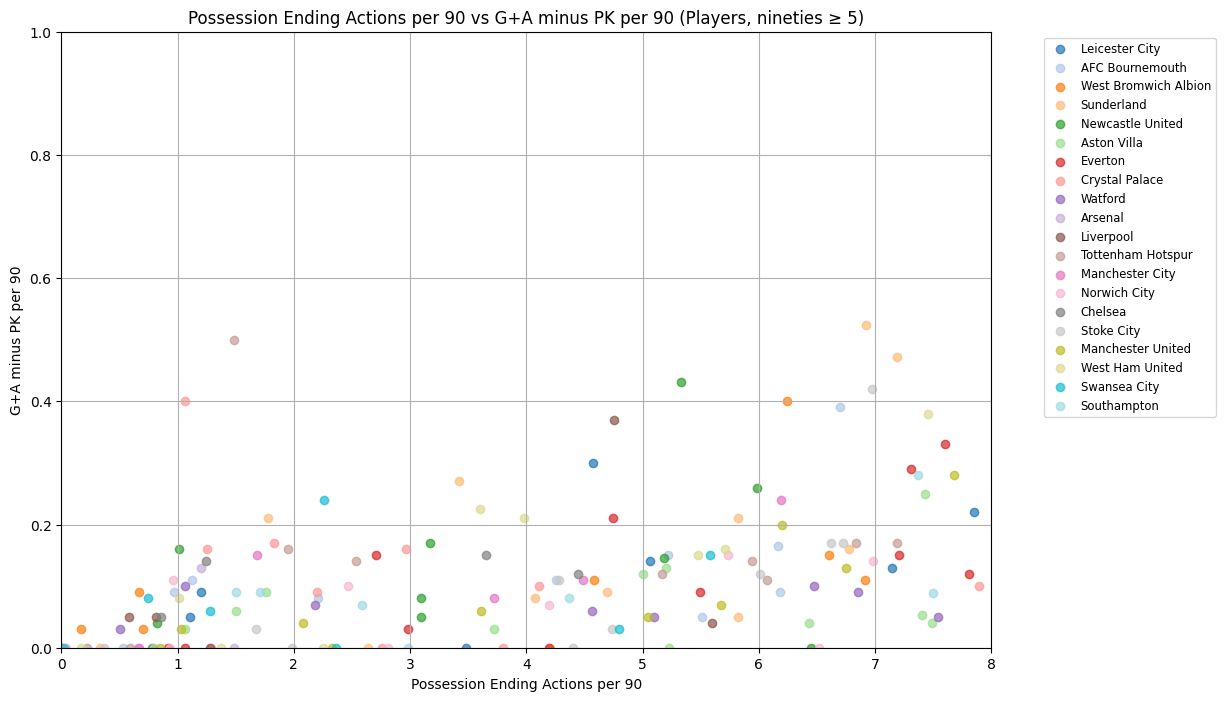

In [47]:
filtered_df = all_players_stats_df[all_players_stats_df['nineties'] >= 5]
teams = filtered_df['team'].unique()
team_colors = {team: plt.cm.tab20(i % 20) for i, team in enumerate(teams)}

plt.figure(figsize=(12,8))
for team in teams:
    df_team = filtered_df[filtered_df['team'] == team]
    plt.scatter(
        df_team['possession_ending_actions_per90'],
        df_team['g_plus_a_minus_pk_p90'],
        color=team_colors[team],
        label=team,
        alpha=0.7
    )
plt.xlabel('Possession Ending Actions per 90')
plt.ylabel('G+A minus PK per 90')
plt.title('Possession Ending Actions per 90 vs G+A minus PK per 90 (Players, nineties ≥ 5)')
plt.xlim(0, 8)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.show()

In [48]:
team_dfs = {}
for team in all_teams:
    team_events = get_team_events(team, matches)
    team_events['x'] = team_events['location'].apply(
        lambda loc: loc[0] if isinstance(loc, (list, tuple)) and len(loc) >= 1 else np.nan
    )
    att_third = team_events[(team_events['x'] >= 80) & (team_events['x'] <= 120)].copy()
    att_third['unsuccessful_dribble'] = (
        (att_third['type'] == 'Dribble') & (att_third['dribble_outcome'] == 'Incomplete')
    ).astype(int)
    team_actions = att_third.groupby('player').agg(
        shots=('type', lambda x: (x == 'Shot').sum()),
        dispossessed=('type', lambda x: (x == 'Dispossessed').sum()),
        miscontrols=('type', lambda x: (x == 'Miscontrol').sum()),
        incomplete_passes=('pass_outcome', lambda x: x.notna().sum()),
        unsuccessful_dribbles=('unsuccessful_dribble', 'sum')
    ).reset_index()
    cols = ['shots','dispossessed','miscontrols','incomplete_passes','unsuccessful_dribbles']
    team_actions[cols] = team_actions[cols].fillna(0).astype(int)
    team_actions['possession_ending_actions'] = team_actions[cols].sum(axis=1)
    team_merged = pd.merge(
        team_actions,
        player_stats,
        left_on='player',
        right_on='player',
        how='inner'
    )
    team_merged['possession_ending_actions_per90'] = team_merged['possession_ending_actions'] / team_merged['nineties']
    team_merged['g_plus_a_minus_pk_p90'] = team_merged['g_plus_a_p90'] - team_merged['penalties_scored'] / team_merged['nineties']
    team_merged['team'] = team
    team_total = team_merged['possession_ending_actions'].sum()
    team_merged['Usage Rate'] = ((team_merged['possession_ending_actions'] / team_total) * 100).round(2)
    team_dfs[team] = team_merged

# Example: view Arsenal's DataFrame
team_dfs['Arsenal'].head()

[12/02/25 18:31:51] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=524814;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=38077;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:32:02] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=189352;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=367153;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:32:12] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=810765;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=376266;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:32:21] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=968398;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=31921;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:32:30] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=137313;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=779805;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

...

[12/02/25 18:34:19] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=543056;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=525514;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:34:28] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=855943;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=278244;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:34:40] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=577101;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=291589;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

[12/02/25 18:34:53] WARNING  C:\Users\jonat\AppData\Local\Temp\ipykernel_17544\971522338.py:4:      ]8;id=636295;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py\warnings.py]8;;\:]8;id=760577;file://c:\Users\jonat\AppData\Local\Programs\Python\Python311\Lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               team_events['x'] = team_events['location'].apply(                                   
                                                                                                                   

,player,shots,dispossessed,miscontrols,incomplete_passes,unsuccessful_dribbles,possession_ending_actions,index,team,nation,...,penalties_attempted,yellow_cards,red_cards,goals_p90,assists_p90,g_plus_a_p90,non_pen_goals_p90,g_plus_a_minus_pk_p90,possession_ending_actions_per90,Usage Rate
0,Aaron Ramsey,67,26,24,142,10,269,0,Arsenal,WAL,...,0,4,0,0.17,0.14,0.31,0.17,0.31,9.243986,17.99
1,Alex Iwobi,15,4,9,35,5,68,1,Arsenal,NGA,...,0,0,0,0.29,0.29,0.57,0.29,0.57,9.714286,4.55
2,Alex Oxlade-Chamberlain,23,22,11,64,8,128,2,Arsenal,ENG,...,0,0,0,0.1,0.0,0.1,0.1,0.1,12.427184,8.56
3,Calum Chambers,2,0,2,3,0,7,4,Arsenal,ENG,...,0,2,0,0.0,0.0,0.0,0.0,0.0,1.944444,0.47
4,Jack Wilshere,1,1,3,5,4,14,10,Arsenal,ENG,...,0,0,0,0.0,0.0,0.0,0.0,0.0,8.75,0.94


In [49]:
team_dfs['Arsenal'][['player'] + list(team_dfs['Arsenal'].columns[-3:])]

,player,g_plus_a_minus_pk_p90,possession_ending_actions_per90,Usage Rate
0,Aaron Ramsey,0.31,9.243986,17.99
1,Alex Iwobi,0.57,9.714286,4.55
2,Alex Oxlade-Chamberlain,0.1,12.427184,8.56
3,Calum Chambers,0.0,1.944444,0.47
4,Jack Wilshere,0.0,8.75,0.94
5,Kieran Gibbs,0.23,8.372093,2.41
6,Laurent Koscielny,0.13,1.202532,2.54
7,Mathieu Debuchy,0.0,9.375,1.00
8,Mathieu Flamini,0.0,1.487603,1.20
9,Mesut Özil,0.74,12.492582,28.16


In [50]:
team_dfs['Leicester City'][['player'] + list(team_dfs['Arsenal'].columns[-3:])]

,player,g_plus_a_minus_pk_p90,possession_ending_actions_per90,Usage Rate
0,Andrej Kramarić,0.0,13.333333,0.18
1,Christian Fuchs,0.13,7.142857,9.83
2,Daniel Amartey,0.0,5.833333,0.32
3,Danny Drinkwater,0.3,4.569733,7.04
4,Danny Simpson,0.0,3.482759,4.62
5,Demarai Gray,0.48,12.857143,1.23
6,Jamie Vardy,0.716322,10.143678,16.13
7,Jeffrey Schlupp,0.19,8.701299,6.12
8,Joe Dodoo,0.0,10.0,0.09
9,Kasper Schmeichel,0.0,0.0,0.00


In [52]:
team_dfs.columns

AttributeError: 'dict' object has no attribute 'columns'